In [387]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
os.getcwd()
import time
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 120
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 80  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("../lib")) # N.B: NB needs this line to run locally!!
import xp as xp
from hamiltonian import inverse_weyl_transform
# import fixed_center_of_mass_exact_3D as fcm
# from plotting import plot_psi3D_fixedPsi, plot_psi3D_fixedPsi_multi, plot_psi3D_BO, fromgpu

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [483]:
ex3D = pd.read_pickle("3D_exact.pkl").sort_index(level=0)
ps3D = pd.read_pickle("3D_PS.pkl").sort_index(level=0)
ps3D_GR = pd.read_pickle("3D_PS_GammaR.pkl").sort_index(level=0)
ps3D_Jl = pd.read_pickle("3D_PS_Jl.pkl").sort_index(level=0)
ps3D_noERF = pd.read_pickle("3D_PS_NO_ERF.pkl").sort_index(level=0)
ps3D_lo = pd.read_pickle("3D_PSlo.pkl").sort_index(level=0)
# ex3D.drop(labels=(15,0), inplace=True)

ex2D = pd.read_pickle("2D_exact.pkl").sort_index(level=0)
ps2D = pd.read_pickle("2D_PS.pkl").sort_index(level=0)
ps2D_noERF = pd.read_pickle("2D_PS_NO_ERF.pkl").sort_index(level=0)

print(ex2D.columns)
print(ps3D.columns)
print(ps3D_GR.columns)
Mass_ex = np.sort(np.unique(np.array(ex3D.index.to_list())[:,0]))
Mass_ps = np.sort(np.unique(np.array(ps3D.index.to_list())[:,0]))
Mass_psG = np.sort(np.unique(np.array(ps3D_GR.index.to_list())[:,0]))
Mass_Jl = np.sort(np.unique(np.array(ps3D_Jl.index.to_list())[:,0]))

Js_3D =  np.sort(np.unique(np.array(ps3D.index.to_list())[:,1]))
Js_2D =  np.sort(np.unique(np.array(ps2D.index.to_list())[:,1]))
print(Mass_ex)
print(Mass_Jl)
print(Js_3D, Js_2D)
# print(Mass_psG)

# print(ex3D)

Index(['gap', 'p01 z', 'p01 r', 'bond length', 'r00', 'r01', 'P01', 'lx00',
       'lx01', 'l200', 'l201'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO', 'lx00 PS', 'lx01 PS', 'l200 PS', 'l201 PS',
       'l200 BO', 'l201 BO'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO'],
      dtype='object')
[  3.   4.   6.   8.  10.  15.  20.  30.  40.  60.  80. 100. 140. 180.
 220. 300.]
[  3.   4.   6.   8.  10.  15.  20.  30.  40.  60.  80. 100. 140. 180.
 220. 300.]
[0. 1. 2. 3. 4. 5. 6.] [   0.    1.    2.    3.    4.    5.    6.   10.   20.   50.  100.  500.
 1000.]


In [478]:
# bo_error = np.abs(ps3D_Jl['BO gap'] -ex3D['gap'])/ex3D['gap']
# ps_error = np.abs(ps3D_Jl['PS gap']-ex3D['gap'])/ex3D['gap']
# ps_no_erf_error = np.abs(ps3D_noERF['PS gap']-ex3D['gap'])/ex3D['gap']

## 3D
bo_error_3d = np.abs(ps3D['BO gap'] -ex3D['gap'])/ex3D['gap']
ps_error_3d = np.abs(ps3D['PS gap']-ex3D['gap'])/ex3D['gap']
ps_no_erf_error_3d = np.abs(ps3D_noERF['PS gap']-ex3D['gap'])/ex3D['gap']
ps_error_3d_lo = np.abs(ps3D_lo['PS gap']-ex3D['gap'])/ex3D['gap']

## 2D
bo_error_2d = np.abs(ps2D['BO gap']-ex2D['gap'])/ex2D['gap']
ps_error_2d = np.abs(ps2D['PS gap']-ex2D['gap'])/ex2D['gap']
ps_no_erf_error_2d = np.abs(ps2D_noERF['PS gap']-ex2D['gap'])/ex2D['gap']



<IPython.core.display.Javascript object>

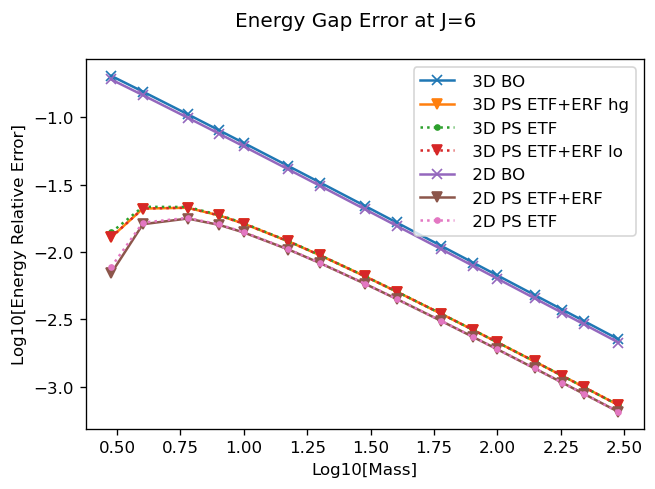

In [480]:
fig,ax = plt.subplots(figsize=(6,4))
Ji = 6
# ax.plot(xp.log10(Mass_ex), xp.log10(bo_error.loc[(slice(None),0)]),marker='x',label="BO")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_error.loc[(slice(None),0)]), marker='s',label="PS ETF+ERF")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error.loc[(slice(None),0)]), marker='s',label="PS ETF", linestyle=":")

ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_3d.loc[(slice(None),Ji)]),marker='x',label=" 3D BO")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_3d.loc[(slice(None),Ji)]), marker='v',label=" 3D PS ETF+ERF hg")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_3d.loc[(slice(None),Ji)]), marker='.',label=" 3D PS ETF", linestyle=":")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_3d.loc[(slice(None),Ji)]), marker='v',label=" 3D PS ETF+ERF lo",  linestyle=":")

ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_2d.loc[(slice(None),Ji)]),marker='x',label=" 2D BO")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_2d.loc[(slice(None),Ji)]), marker='v',label=" 2D PS ETF+ERF")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_2d.loc[(slice(None),Ji)]), marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(psG_error.loc[(slice(None),0)]), marker='.',label="PS w Gamma/R", linestyle="--")

ax.set_xlabel("Log10[Mass]")
ax.set_ylabel("Log10[Energy Relative Error]")
ax.legend()
fig.suptitle("Energy Gap Error at J={}".format(Ji))
display(fig)

<IPython.core.display.Javascript object>

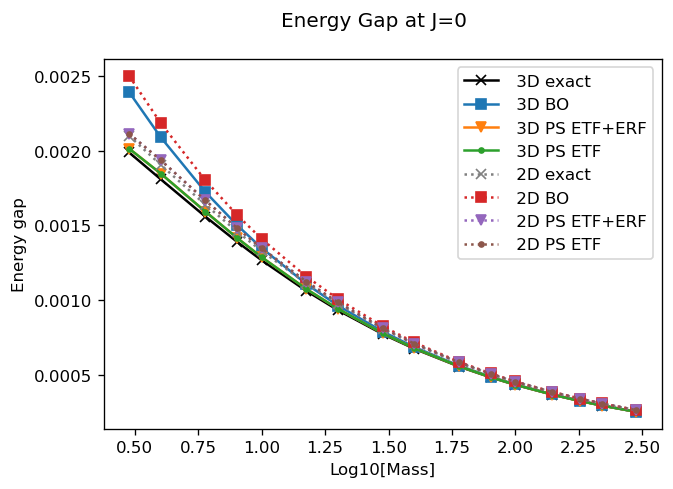

In [428]:
fig,ax = plt.subplots(figsize=(6,4))
Ji = 0

ax.plot(xp.log10(Mass_ex), ex3D['gap'].loc[(slice(None),Ji)],marker='x',color='k',label=" 3D exact")
ax.plot(xp.log10(Mass_ex), ps3D['BO gap'].loc[(slice(None),Ji)],marker='s',label=" 3D BO")
ax.plot(xp.log10(Mass_ex), ps3D['PS gap'].loc[(slice(None),Ji)], marker='v',label=" 3D PS ETF+ERF")
ax.plot(xp.log10(Mass_ex), ps3D_noERF['PS gap'].loc[(slice(None),Ji)], marker='.',label=" 3D PS ETF")

ax.plot(xp.log10(Mass_ex), ex2D['gap'].loc[(slice(None),Ji)],marker='x',color='grey',label=" 2D exact", linestyle=":")
ax.plot(xp.log10(Mass_ex), ps2D['BO gap'].loc[(slice(None),Ji)],marker='s',label=" 2D BO", linestyle=":")
ax.plot(xp.log10(Mass_ex), ps2D['PS gap'].loc[(slice(None),Ji)], marker='v',label=" 2D PS ETF+ERF", linestyle=":")
ax.plot(xp.log10(Mass_ex), ps2D_noERF['PS gap'].loc[(slice(None),Ji)], marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_2d.loc[(slice(None),Ji)]),marker='x',label=" 2D BO")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_2d.loc[(slice(None),Ji)]), marker='v',label=" 2D PS ETF+ERF")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_2d.loc[(slice(None),Ji)]), marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(psG_error.loc[(slice(None),0)]), marker='.',label="PS w Gamma/R", linestyle="--")

ax.set_xlabel("Log10[Mass]")
ax.set_ylabel("Energy gap")
# ax.set_ylabel("Log10[Energy Relative Error]")
ax.legend()
fig.suptitle("Energy Gap at J={}".format(Ji))
display(fig)

<IPython.core.display.Javascript object>

/tmp/ipykernel_145736/2971188172.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
/tmp/ipykernel_145736/2971188172.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
/tmp/ipykernel_145736/2971188172.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(No

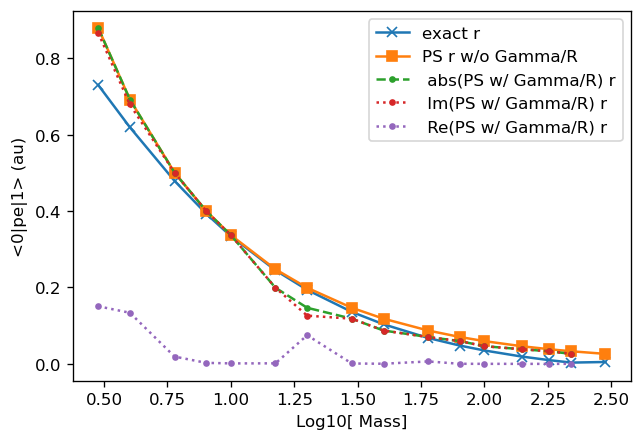

In [429]:
fig,ax = plt.subplots(figsize=(6,4))

ax.plot(np.log10(Mass_ex), np.abs(ex3D['p01 r'].loc[(slice(None),0)])   ,'x-',label='exact r')
ax.plot(np.log10(Mass_ps), np.abs(ps3D['momentum r'].loc[(slice(None),0)]),'s-',label="PS r w/o Gamma/R" )
ax.plot(np.log10(Mass_ps[:-1]), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).real),'.-',label=" Re(PS w/ Gamma/R) r" , linestyle=":")

# ax.plot(np.log10(Mass_ps), np.abs(ps3D['momentum r'].loc[(slice(None),0)])- np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'s-',label="PS r w/o Gamma/R" )
# ax.plot(np.log10(Mass_ps), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)])-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
# ax.plot(np.log10(Mass_ps), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag)-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
# # ax.plot(np.log10(Mass_ps), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).real)-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" Re(PS w/ Gamma/R) r" , linestyle=":")

# ax.set_ylim(-0.1,.9)
ax.set_xlabel("Log10[ Mass]")
ax.set_ylabel("<0|pe|1> (au)")
# ax.set_ylabel("<0|pe|1> Difference from exact")
ax.legend()

display(fig)

<IPython.core.display.Javascript object>

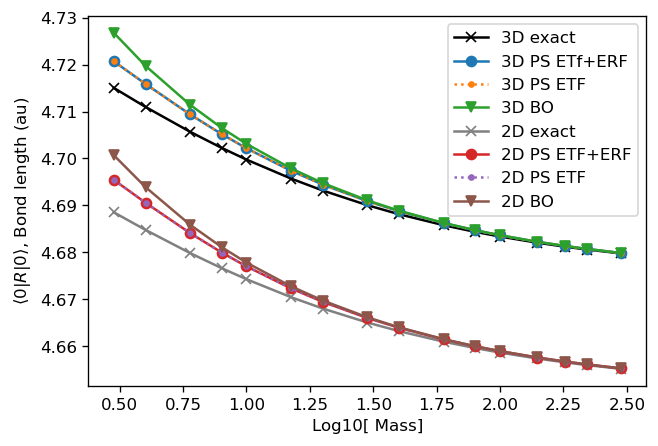

In [583]:
fig,ax = plt.subplots(figsize=(6,4))

ax.plot(np.log10(Mass_ex), np.abs(ex3D['bond length'].loc[(slice(None),0)]),'x-',color='k', label="3D exact")
ax.plot(np.log10(Mass_ps), np.abs(ps3D['bond length PS'].loc[(slice(None),0)]),'o-', label="3D PS ETf+ERF")
ax.plot(np.log10(Mass_ps), np.abs(ps3D_noERF['bond length PS'].loc[(slice(None),0)]),'.:', label="3D PS ETF")
ax.plot(np.log10(Mass_ps), np.abs(ps3D['bond length BO'].loc[(slice(None),0)]),'v-', label="3D BO")

ax.plot(np.log10(Mass_ex), np.abs(ex2D['bond length'].loc[(slice(None),0)]),'x-',color='grey', label="2D exact")
ax.plot(np.log10(Mass_ps), np.abs(ps2D['bond length PS'].loc[(slice(None),0)]),'o-', label="2D PS ETF+ERF")
ax.plot(np.log10(Mass_ps), np.abs(ps2D_noERF['bond length PS'].loc[(slice(None),0)]),'.:', label="2D PS ETF")
ax.plot(np.log10(Mass_ps), np.abs(ps2D['bond length BO'].loc[(slice(None),0)]),'v-', label="2D BO")



ax.set_xlabel("Log10[ Mass]")
ax.set_ylabel(r"$\langle0|R|0\rangle$, Bond length (au)")
ax.legend()

display(fig)

<IPython.core.display.Javascript object>

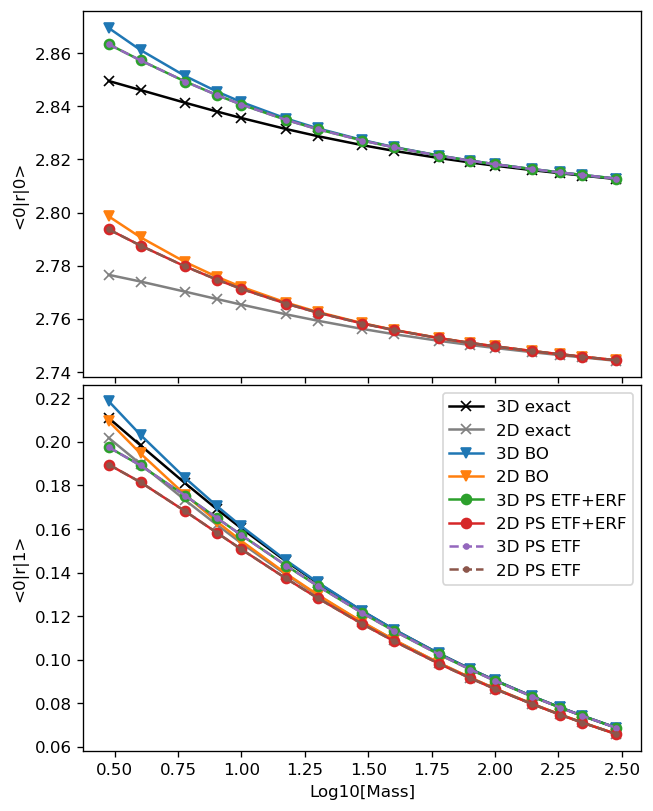

In [437]:
fig,ax = plt.subplots(nrows=2, figsize=(6,8), sharex=True)
Ji=0
ax[0].plot(np.log10(Mass_ex), np.abs(ex3D['r00'].loc[(slice(None),Ji)]),'x-', label="3Dexact", color='k')
ax[1].plot(np.log10(Mass_ex), np.abs(ex3D['r01'].loc[(slice(None),Ji)]),'x-', label="3D exact", color='k')
ax[0].plot(np.log10(Mass_ex), np.abs(ex2D['r00'].loc[(slice(None),Ji)]),'x-', label="2Dexact", color='grey')
ax[1].plot(np.log10(Mass_ex), np.abs(ex2D['r01'].loc[(slice(None),Ji)]),'x-', label="2D exact", color='grey')

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")

ax[1].set_xlabel("Log10[Mass]")
ax[0].set_ylabel("<0|r|0>")
ax[1].set_ylabel("<0|r|1>")

ax[1].legend()
fig.subplots_adjust(hspace=0.02)
display(fig)

<IPython.core.display.Javascript object>

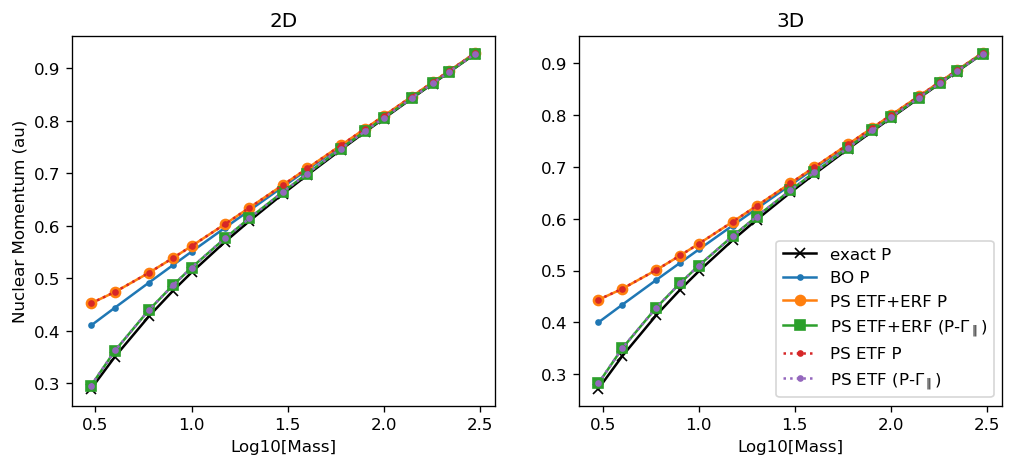

In [545]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
Ji = 6
ax[1].plot(xp.log10(Mass_ex), np.log10(ex3D['P01'].loc[(slice(None),Ji)]), 'x-', label="exact P", color='k')
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 BO'].loc[(slice(None),Ji)]), '.-', label="BO P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label="PS ETF+ERF P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P-$\Gamma_\parallel$)")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label="PS ETF P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P-$\Gamma_\parallel$)")

ax[0].plot(xp.log10(Mass_ex), np.log10(ex2D['P01'].loc[(slice(None),Ji)]), 'x-', label="exact P", color='k')
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 BO'].loc[(slice(None),Ji)]), '.-', label="BO P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label="PS ETF+ERF P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P-$\Gamma_\parallel$)")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label="PS ETF P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P-$\Gamma_\parallel$)")

ax[0].set_title("2D")
ax[1].set_title("3D")
ax[0].set_xlabel("Log10[Mass]")
ax[0].set_ylabel("Nuclear Momentum (au)")
ax[1].set_xlabel("Log10[Mass]")
ax[1].legend()
display(fig)

<IPython.core.display.Javascript object>

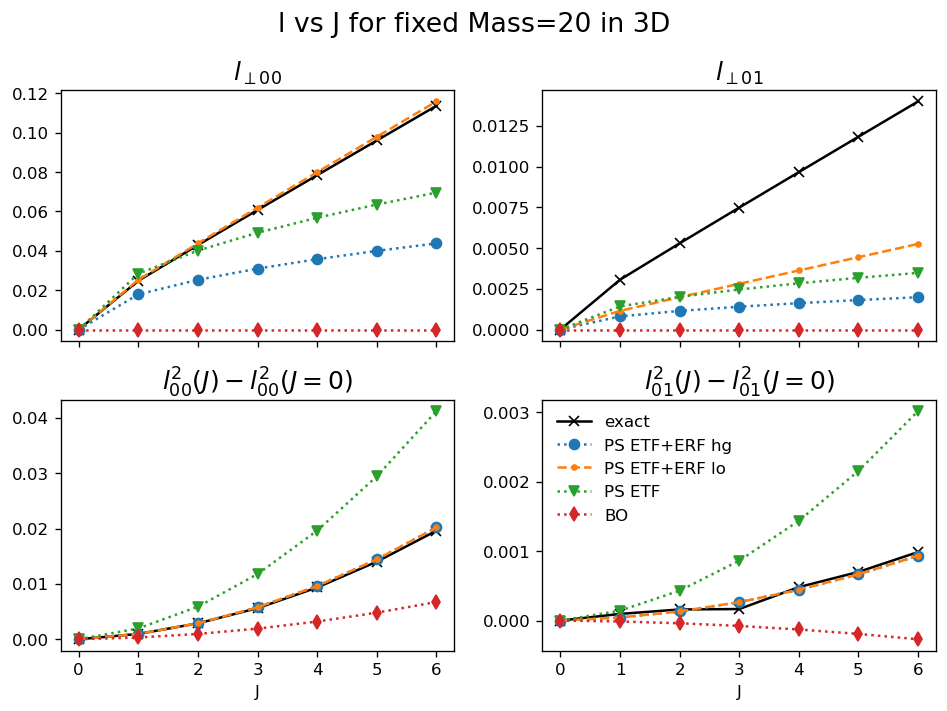

In [550]:
fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(8,6))
M=20

fig.suptitle("l vs J for fixed Mass={} in 3D".format(M), fontsize=16)
ax[0,0].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), '.--', label='3D PS ETF+ERF lo')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
ax[0,0].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

# ax[0,0].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), '.--', label='3D PS ETF+ERF lo')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
# ax[0,0].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

# ax[0,0].plot(Js_2D, ex2D['lx00'].loc[(M,slice(None))], 'x-', label='2D exact', color='grey')
# ax[0,0].plot(Js_2D , xp.abs(xp.asarray(ps2D['lx00 PS'].loc[(M,slice(None))]).real), '.-', label='3D PS ETF+ERF')
# ax[0,0].plot(Js_2D , xp.abs(xp.asarray(ps2D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v-', label='PS ETF')

ax[0,1].plot(Js_ps, xp.abs(ex3D['lx01'].loc[(10,slice(None))]), 'x-', label='exact', color='k')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['lx01 PS'].loc[(M,slice(None))]).real), 'o:', label='PS ETF+ERF hg')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['lx01 PS'].loc[(M,slice(None))]).real), '.--', label='PS ETF+ERF lo')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['lx01 PS'].loc[(M,slice(None))]).real), 'v:', label='PS ETF')
ax[0,1].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

ax[1,0].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))] -ex3D['l200'].loc[(M,0)], 'x-', label='exact', color='k')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 PS'].loc[(M,slice(None))]).real)-(ps3D['l200 PS'].loc[(M,0)]), 'o:', label='PS ETF+ERF hg')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_lo['l200 PS'].loc[(M,0)]), '.--', label='PS ETF+ERF lo')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_noERF['l200 PS'].loc[(M,0)]), 'v:', label='PS ETF')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 BO'].loc[(M,slice(None))]).real)-(ps3D['l200 BO'].loc[(M,0)]), 'd:', label='BO')
# # ax[1,0].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))]-ex3D['l200'].loc[(M,0)], 'x-', label='exact')
# # ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real)-ex3D['l200'].loc[(M,0)], '.-', label='PS ETF')

ax[1,1].plot(Js_ps, xp.abs(ex3D['l201'].loc[(M,slice(None))])-ex3D['l201'].loc[(M,0)], 'x-', label='exact', color='k')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D['l201 PS'].loc[(M,0)]), 'o:', label='PS ETF+ERF hg')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D_lo['l201 PS'].loc[(M,0)]), '.--', label='PS ETF+ERF lo')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D_noERF['l201 PS'].loc[(M,0)]), 'v:', label='PS ETF')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 BO'].loc[(M,slice(None))]).real)-xp.abs((ps3D['l201 BO'].loc[(M,0)])), 'd:', label='BO')

# ax[1,1].plot(Js_ps, xp.abs(ex3D['l201'].loc[(M,slice(None))])-ex3D['l200'].loc[(M,0)], 'x-', label='exact')
# ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_Jl['l201 PS'].loc[(M,slice(None))]).real)-ex3D['l201'].loc[(M,0)], '.-', label='PS ETF+ERF')
# ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l201 PS'].loc[(M,slice(None))]).real)-ex3D['l201'].loc[(M,0)], 'v-', label='PS ETF')

ax[0,0].set_title(r"$l_{\perp 00}$", fontsize=15)
ax[0,1].set_title(r"$l_{\perp 01}$", fontsize=15)
ax[1,0].set_title(r"$l^2_{00}(J) - l^2_{00}(J=0)$", fontsize=15)
ax[1,1].set_title(r"$l^2_{01}(J) - l^2_{01}(J=0)$", fontsize=15)
ax[1,0].set_xlabel("J")
ax[1,1].set_xlabel("J")
ax[1,0].set_xticks(Js_3D)
ax[1,1].set_xticks(Js_3D)
ax[1,1].legend(frameon=False)
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

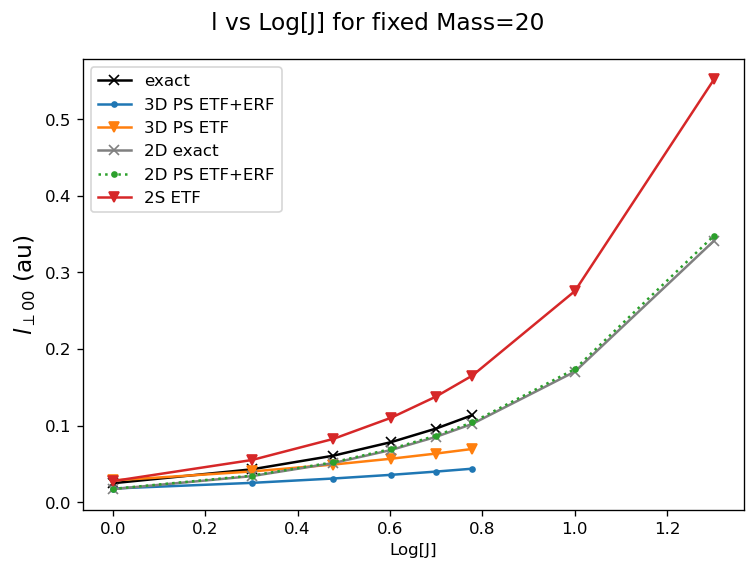

In [470]:
# fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True)
fig,ax = plt.subplots()
M=20

fig.suptitle("l vs Log[J] for fixed Mass={}".format(M), fontsize=14)
ax.plot(xp.log10(Js_3D[1:]), ex3D['lx00'].loc[(M,Js_3D[1:])], 'x-', label='exact', color='k')
ax.plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_Jl['lx00 PS'].loc[(M,Js_3D[1:])]).real), '.-', label='3D PS ETF+ERF')
ax.plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,Js_3D[1:])]).real), 'v-', label='3D PS ETF')

ax.plot(xp.log10(Js_2D[1:-4]), xp.abs(ex2D['lx00'].loc[(M,Js_2D[1:-4])]), 'x-', label='2D exact', color='grey')
ax.plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D['lx00 PS'].loc[(M,Js_2D[1:-4])]).real), '.:', label='2D PS ETF+ERF')
ax.plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D_noERF['lx00 PS'].loc[(M,Js_2D[1:-4])]).real), 'v-', label='2S ETF')

ax.set_ylabel(r"$l_{\perp 00}$ (au)", fontsize=14)
# ax[0,1].set_title(r"$l_{x01}$")
# ax[1,0].set_title(r"$l^2_{00}$")
# ax[1,1].set_title(r"$l^2_{01}$")
ax.set_xlabel("Log[J]")
# ax.set_xlabel("J")
ax.legend()
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

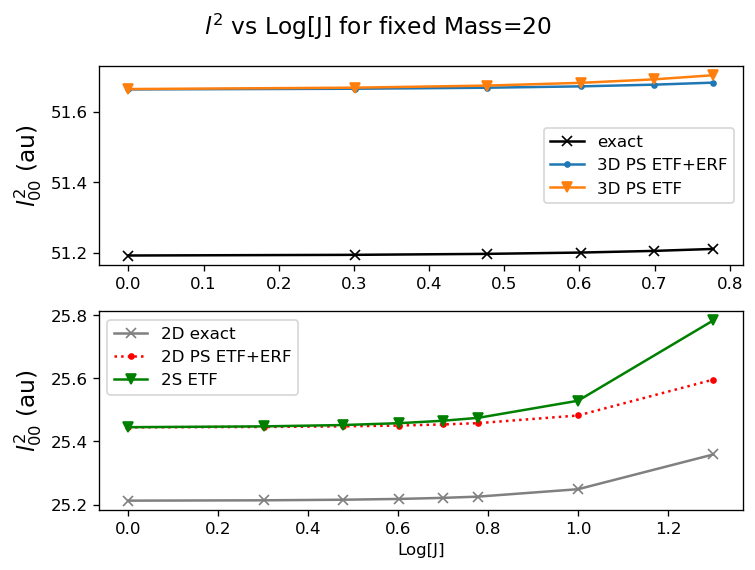

In [475]:
fig,ax = plt.subplots(nrows=2)
M=20

fig.suptitle(r"$l^2$ vs Log[J] for fixed Mass={}".format(M), fontsize=14)
ax[0].plot(xp.log10(Js_3D[1:]), ex3D['l200'].loc[(M,Js_3D[1:])], 'x-', label='exact', color='k')
ax[0].plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_Jl['l200 PS'].loc[(M,Js_3D[1:])]).real), '.-', label='3D PS ETF+ERF')
ax[0].plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,Js_3D[1:])]).real), 'v-', label='3D PS ETF')

ax[1].plot(xp.log10(Js_2D[1:-4]), xp.abs(ex2D['l200'].loc[(M,Js_2D[1:-4])]), 'x-', label='2D exact', color='grey')
ax[1].plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D['l200 PS'].loc[(M,Js_2D[1:-4])]).real), '.:', label='2D PS ETF+ERF', color='r')
ax[1].plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D_noERF['l200 PS'].loc[(M,Js_2D[1:-4])]).real), 'v-', label='2S ETF', color='g')

ax[0].set_ylabel(r"$l^2_{00}$ (au)", fontsize=14)
ax[1].set_ylabel(r"$l^2_{00}$ (au)", fontsize=14)
# ax[0,1].set_title(r"$l_{x01}$")
# ax[1,0].set_title(r"$l^2_{00}$")
# ax[1,1].set_title(r"$l^2_{01}$")
ax[1].set_xlabel("Log[J]")
# ax.set_xlabel("J")
ax[0].legend()
ax[1].legend()
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

/tmp/ipykernel_145736/3615049646.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend(frameon=False)


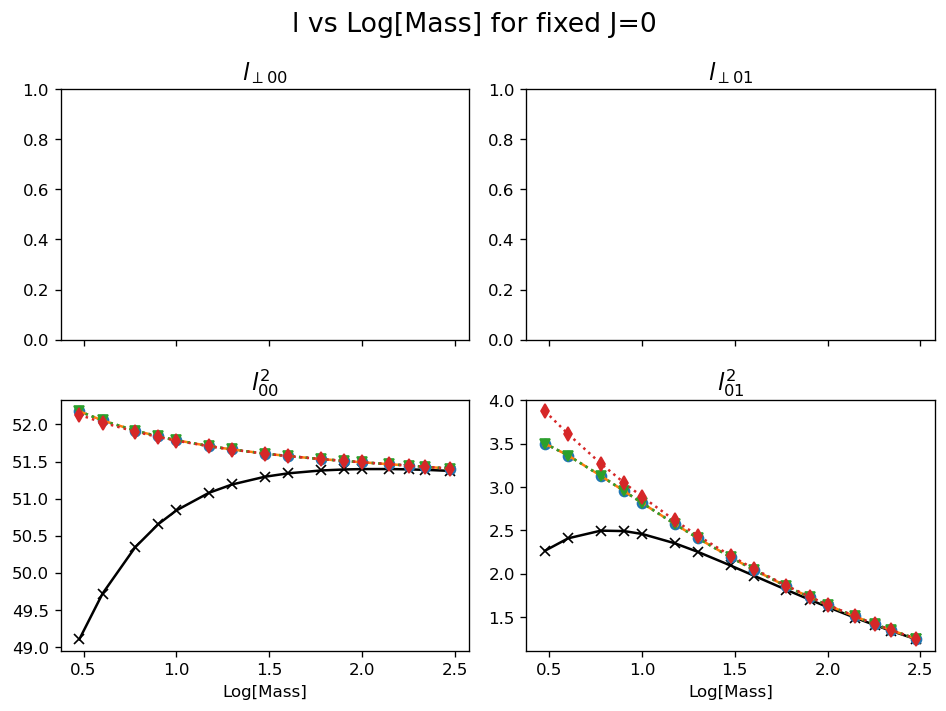

In [556]:
fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(8,6))
Ji=0
fig.suptitle("l vs Log[Mass] for fixed J={}".format(Ji), fontsize=16)
# ax[0,0].plot(np.log10(Mass_ex), xp.abs(ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
# ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[0,0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")

# ax[0,0].plot(np.log10(Mass_ex), (ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')

# ax[0,0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label=
# ax[0,1].plot(np.log10(Mass_ex), xp.abs(ex3D['lx01'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx01 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx01 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF hg')
# ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx01 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[0,1].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")

# # ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex3D['l200'].loc[(slice(None),Ji)])-xp.abs(ex3D['l200'].loc[(300,Ji)]), 'x-', label='exact', color='k')
# # ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex2D['l200'].loc[(slice(None),Ji)])-xp.abs(ex2D['l200'].loc[(300,Ji)]), 'x-', label='exact', color='purple')
ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex3D['l200'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['l200 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['l200 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 BO'].loc[(slice(None)),Ji])), 'd:', label='PS ETF+ERF hg')

ax[1,1].plot(np.log10(Mass_ex), xp.abs(ex3D['l201'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l201 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['l201 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['l201 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l201 BO'].loc[(slice(None)),Ji])), 'd:', label='BO')

# print(Mass_Jl)
# print(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])

ax[0,0].set_title(r"$l_{\perp 00}$", fontsize=14)
ax[0,1].set_title(r"$l_{\perp 01}$", fontsize=14)
ax[1,0].set_title(r"$l^2_{00}$", fontsize=14)
ax[1,1].set_title(r"$l^2_{01}$", fontsize=14)
ax[1,0].set_xlabel("Log[Mass]")
ax[1,1].set_xlabel("Log[Mass]")
ax[0,1].legend(frameon=False)
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

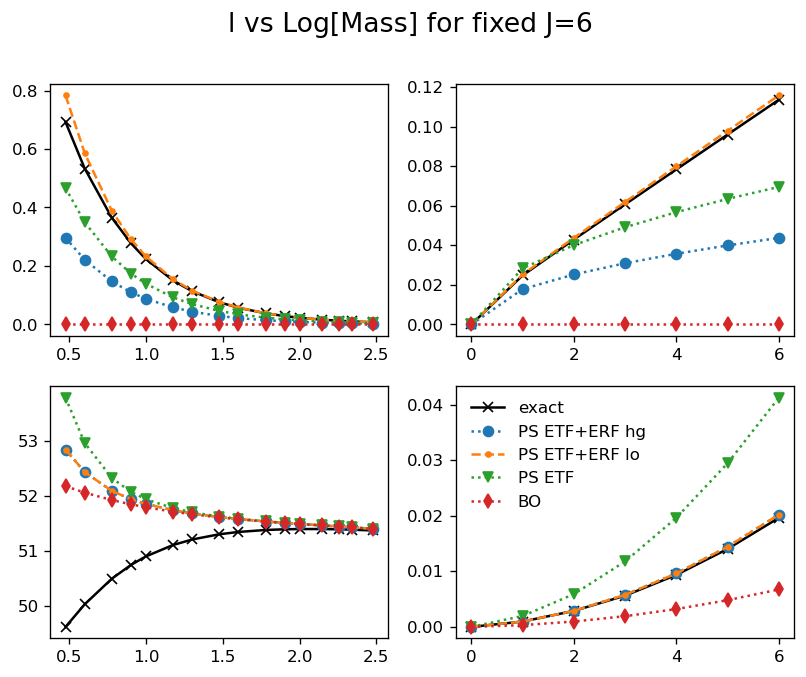

In [540]:
fig,ax = plt.subplots(nrows=2, ncols=2, figsize=(8,6))
Ji=6
M=20
fig.suptitle("l vs Log[Mass] for fixed J={}".format(Ji), fontsize=16)
ax[0,0].plot(np.log10(Mass_ex), xp.abs(ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[0,0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")

ax[0,1].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
ax[0,1].plot(Js_3D , xp.abs(xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
ax[0,1].plot(Js_3D , xp.abs(xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), '.--', label='3D PS ETF+ERF lo')
ax[0,1].plot(Js_3D , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
ax[0,1].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex3D['l200'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['l200 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['l200 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 BO'].loc[(slice(None)),Ji])), 'd:', label='PS ETF+ERF hg')

ax[1,1].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))] -ex3D['l200'].loc[(M,0)], 'x-', label='exact', color='k')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 PS'].loc[(M,slice(None))]).real)-(ps3D['l200 PS'].loc[(M,0)]), 'o:', label='PS ETF+ERF hg')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_lo['l200 PS'].loc[(M,0)]), '.--', label='PS ETF+ERF lo')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_noERF['l200 PS'].loc[(M,0)]), 'v:', label='PS ETF')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 BO'].loc[(M,slice(None))]).real)-(ps3D['l200 BO'].loc[(M,0)]), 'd:', label='BO')

ax[1,1].legend(frameon=False)

display(fig)

In [447]:
ex3D['lx00'].loc[(220,Js_3D[1:])]

Mass  J  
220   1.0    0.002275+0.000000j
      2.0    0.003960+0.000000j
      3.0    0.005584+0.000000j
      4.0    0.007207+0.000000j
      5.0    0.008831+0.000000j
      6.0    0.010448+0.000000j
Name: lx00, dtype: complex128

<IPython.core.display.Javascript object>

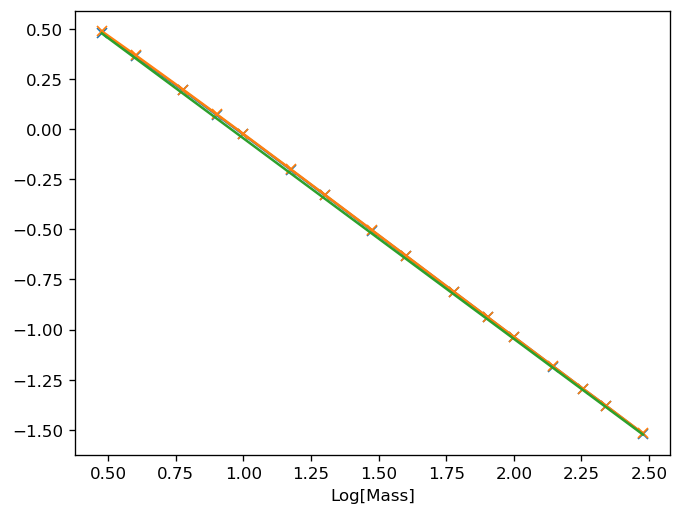

In [585]:
fig,ax = plt.subplots()

ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 BO'].loc[(Mass_ps,0)]), 'x-')
ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 PS'].loc[(Mass_ps,0)]), 'x-')
ax.plot(xp.log10(Mass_ex), xp.log10(9/Mass_ex))

ax.set_xlabel("Log[Mass]")
# ax.set_ylabel
display(fig)

In [574]:
ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 BO'].loc[(Mass_ps,0)]

Mass  J  
3     0.0   -3.025284+0.000000j
4     0.0   -2.305307+0.000000j
6     0.0   -1.557408+0.000000j
8     0.0   -1.173451-0.000000j
10    0.0   -0.940217-0.000000j
15    0.0   -0.626437-0.000000j
20    0.0   -0.468830-0.000000j
30    0.0   -0.311168-0.000000j
40    0.0   -0.232615+0.000000j
60    0.0   -0.154213+0.000000j
80    0.0   -0.115203-0.000000j
100   0.0   -0.091878-0.000000j
140   0.0   -0.065413-0.000000j
180   0.0   -0.050694-0.000000j
220   0.0   -0.041518+0.000000j
300   0.0   -0.030247+0.000000j
dtype: complex128